# Lab N°2 : Classification with Fully Connected Neural Networks (FCNN)

**Module : Deep Learning — INSAT**  
**Sections : GL4, RT4 | Year : 2023-2024**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

---
## Part I : Binary Classification

### 1. Dataset

In [ ]:
# a. Create data with make_circles
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)

In [ ]:
# b. Dataset dimensions
print("Dimensions of X (input) :", X.shape)   # 1000 samples, 2 features
print("Dimensions of y (output) :", y.shape)   # 1000 binary labels (0 or 1)

# Input has 2 dimensions (x1, x2) and output is scalar (class 0 or 1)

Dimensions de X (entrée) : (1000, 2)
Dimensions de y (sortie) : (1000,)


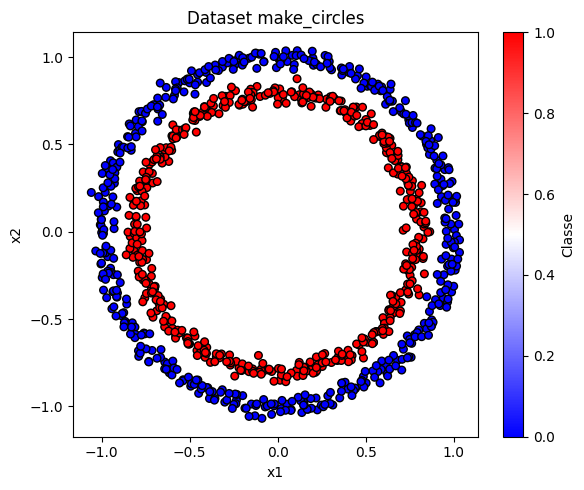

In [ ]:
# c. Data visualization
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=30)
plt.title("Dataset make_circles")
plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(label='Class')
plt.tight_layout()
plt.show()

**d. Linear or non-linear function?**

This dataset requires a **non-linear function**. The two classes form concentric circles: no straight line can separate them. Therefore, a curved decision boundary is needed, which neural networks with non-linear activations can provide.

In [ ]:
# e. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size :", X_train.shape[0])  # 800 samples
print("Test size  :", X_test.shape[0])   # 200 samples

Taille train : 800
Taille test  : 200


### 2. FCNN Model Definition

In [ ]:
# 2.2 Model definition
# Architecture : Input(2) -> Dense(100, relu) -> Dense(1, sigmoid)
# Note : the lab figure shows 5 hidden neurons, but the text asks for 100.
# We follow the text.

model = Sequential([
    tf.keras.Input((2,)),
    Dense(100, activation='relu'),  # hidden layer
    Dense(1, activation='sigmoid')                    # output layer (binary)
])

# b. Model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 100)                 │             300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 2.3 Model compilation
# Loss : binary_crossentropy (binary classification)
# Optimizer : SGD (Stochastic Gradient Descent)

model.compile(
    loss='binary_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

In [ ]:
# 2.4 Model training for 100 epochs
# verbose=0 to avoid default output, we will display every 10 epochs manually

history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    verbose=0
)

# Display every 10 epochs
print(f"{'Epoch':>8} {'Loss':>10} {'Accuracy':>10} {'Val Loss':>10} {'Val Accuracy':>14}")
print("-" * 55)
for epoch in range(9, 100, 10):
    loss = history.history['loss'][epoch]
    acc  = history.history['accuracy'][epoch]
    vl   = history.history['val_loss'][epoch]
    va   = history.history['val_accuracy'][epoch]
    print(f"{epoch+1:>8} {loss:>10.4f} {acc:>10.4f} {vl:>10.4f} {va:>14.4f}")

  Epoque       Loss   Accuracy   Val Loss   Val Accuracy
-------------------------------------------------------
      10     0.6950     0.5063     0.6982         0.4600
      20     0.6914     0.5038     0.6956         0.4500
      30     0.6884     0.5138     0.6932         0.4700
      40     0.6855     0.5500     0.6909         0.4950
      50     0.6827     0.5900     0.6886         0.5200
      60     0.6798     0.6187     0.6862         0.5500
      70     0.6769     0.6475     0.6836         0.5600
      80     0.6736     0.6662     0.6808         0.5850
      90     0.6707     0.6837     0.6783         0.5950
     100     0.6676     0.7000     0.6756         0.6200


### 2.5 Model Evaluation

In [ ]:
# Utility function to plot the decision boundary
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
    y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
    Z = (Z > 0.5).astype(int).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', s=20)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")

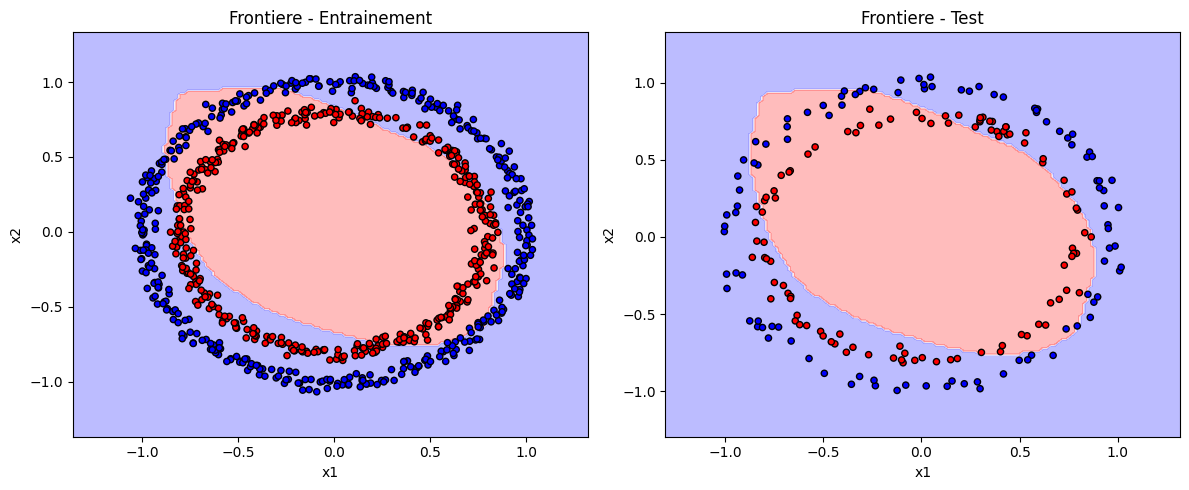

In [ ]:
# 1. Decision boundaries for train and test
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plt.sca(axes[0])
plot_decision_boundary(model, X_train, y_train, "Boundary - Training")

plt.sca(axes[1])
plot_decision_boundary(model, X_test, y_test, "Boundary - Test")

plt.tight_layout()
plt.show()

**2. Problem with the model:**

With a single hidden layer and basic SGD optimizer, the model may struggle to converge properly. The resulting decision boundary is likely to be too simple (underfitting) or unstable. Accuracy remains low because:
- The default learning rate of SGD is sometimes too small or too large.
- A single layer may lack representational capacity for this non-linear problem.

**3. How to improve the model? 3 techniques:**

1. **Change the optimizer**: Use Adam instead of SGD. Adam adapts the learning rate automatically and converges much faster.
2. **Add hidden layers**: A deeper network can better capture the non-linearity of the data.
3. **Increase the number of epochs**: Let the model train longer to better minimize the loss.

We will implement the **combination of solutions 1 and 2** below.

In [ ]:
# Improved model: more layers + Adam optimizer
model_improved = Sequential([
    tf.keras.Input((2,)),
    Dense(100, activation='relu'),
    Dense(50,  activation='relu'),
    Dense(1,   activation='sigmoid')
])

model_improved.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_imp = model_improved.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    verbose=0
)

print(f"{'Epoch':>8} {'Loss':>10} {'Accuracy':>10} {'Val Loss':>10} {'Val Accuracy':>14}")
print("-" * 55)
for epoch in range(9, 100, 10):
    loss = history_imp.history['loss'][epoch]
    acc  = history_imp.history['accuracy'][epoch]
    vl   = history_imp.history['val_loss'][epoch]
    va   = history_imp.history['val_accuracy'][epoch]
    print(f"{epoch+1:>8} {loss:>10.4f} {acc:>10.4f} {vl:>10.4f} {va:>14.4f}")

  Epoque       Loss   Accuracy   Val Loss   Val Accuracy
-------------------------------------------------------
      10     0.4960     0.9712     0.4936         0.9500
      20     0.0916     1.0000     0.1168         1.0000
      30     0.0305     1.0000     0.0500         1.0000
      40     0.0157     1.0000     0.0317         1.0000
      50     0.0097     1.0000     0.0235         1.0000
      60     0.0067     1.0000     0.0185         1.0000
      70     0.0049     1.0000     0.0151         1.0000
      80     0.0037     1.0000     0.0127         1.0000
      90     0.0030     1.0000     0.0110         1.0000
     100     0.0024     1.0000     0.0096         1.0000


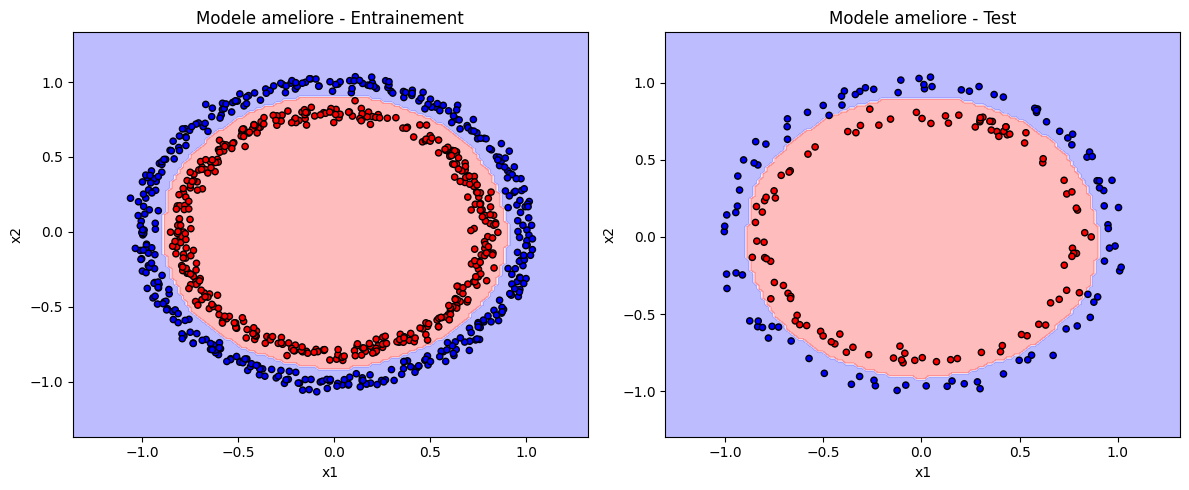

In [ ]:
# Decision boundaries of the improved model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plt.sca(axes[0])
plot_decision_boundary(model_improved, X_train, y_train, "Improved model - Training")

plt.sca(axes[1])
plot_decision_boundary(model_improved, X_test, y_test, "Improved model - Test")

plt.tight_layout()
plt.show()

---
## Part II : Multi-Classification

In [14]:
# 1. Créer les données multi-classes avec make_blobs
X_mc, y_mc = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=4,
    random_state=42
)

In [15]:
# 2. Division train/test
X_mc_train, X_mc_test, y_mc_train, y_mc_test = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42
)

print("Taille train :", X_mc_train.shape[0])
print("Taille test  :", X_mc_test.shape[0])
print("Classes      :", np.unique(y_mc))

Taille train : 800
Taille test  : 200
Classes      : [0 1 2 3]


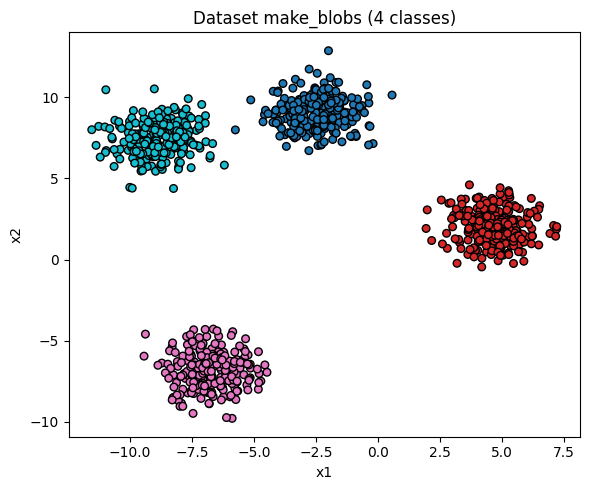

In [16]:
# 3. Visualisation des données
plt.figure(figsize=(6, 5))
plt.scatter(X_mc[:, 0], X_mc[:, 1], c=y_mc, cmap='tab10', edgecolors='k', s=30)
plt.title("Dataset make_blobs (4 classes)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.tight_layout()
plt.show()

**4. Fonction linéaire ou non linéaire ?**

Les données `make_blobs` forment des groupes (clusters) bien séparés et globalement linéairement séparables. Une frontière linéaire (ou quasi-linéaire) suffit en théorie. Cependant, un réseau de neurones avec des activations non linéaires peut tout de même s'en charger efficacement.

In [18]:
# 5. Architecture FCNN pour la multi-classification
# Sortie : 4 neurones avec activation softmax (une probabilité par classe)

model_mc = Sequential([
    tf.keras.Input((2,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(4,  activation='softmax')   # 4 classes
])

model_mc.compile(
    loss='sparse_categorical_crossentropy',  # labels entiers (0,1,2,3)
    optimizer='adam',
    metrics=['accuracy']
)

model_mc.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                     │ (None, 64)                  │             192 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 4)                   │             132 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,404 (9.39 KB)

 Trainable params: 2,404 (9.39 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# 6. Entrainement du modèle multi-classe
history_mc = model_mc.fit(
    X_mc_train, y_mc_train,
    epochs=100,
    validation_data=(X_mc_test, y_mc_test),
    verbose=0
)

print(f"{'Epoque':>8} {'Loss':>10} {'Accuracy':>10} {'Val Loss':>10} {'Val Accuracy':>14}")
print("-" * 55)
for epoch in range(9, 100, 10):
    loss = history_mc.history['loss'][epoch]
    acc  = history_mc.history['accuracy'][epoch]
    vl   = history_mc.history['val_loss'][epoch]
    va   = history_mc.history['val_accuracy'][epoch]
    print(f"{epoch+1:>8} {loss:>10.4f} {acc:>10.4f} {vl:>10.4f} {va:>14.4f}")

  Epoque       Loss   Accuracy   Val Loss   Val Accuracy
-------------------------------------------------------
      10     0.0080     0.9987     0.0057         1.0000
      20     0.0036     0.9987     0.0022         1.0000
      30     0.0027     0.9987     0.0014         1.0000
      40     0.0023     0.9987     0.0010         1.0000
      50     0.0021     0.9987     0.0008         1.0000
      60     0.0020     0.9987     0.0007         1.0000
      70     0.0019     0.9987     0.0006         1.0000
      80     0.0018     0.9987     0.0005         1.0000
      90     0.0017     0.9987     0.0005         1.0000
     100     0.0017     0.9987     0.0004         1.0000


In [20]:
# 7. Métriques de classification
y_pred_proba = model_mc.predict(X_mc_test, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

print("=== Rapport de classification ===")
print(classification_report(y_mc_test, y_pred,
                             target_names=['Classe 0','Classe 1','Classe 2','Classe 3']))

print("=== Matrice de confusion ===")
cm = confusion_matrix(y_mc_test, y_pred)
print(cm)

=== Rapport de classification ===
              precision    recall  f1-score   support

    Classe 0       1.00      1.00      1.00        49
    Classe 1       1.00      1.00      1.00        41
    Classe 2       1.00      1.00      1.00        53
    Classe 3       1.00      1.00      1.00        57

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

=== Matrice de confusion ===
[[49  0  0  0]
 [ 0 41  0  0]
 [ 0  0 53  0]
 [ 0  0  0 57]]


**Interprétation des métriques :**

- **Précision (Precision)** : Parmi les échantillons prédits comme appartenant à une classe, combien sont réellement de cette classe. Une précision élevée signifie peu de faux positifs.

- **Rappel (Recall)** : Parmi les échantillons qui appartiennent réellement à une classe, combien ont été correctement détectés. Un rappel élevé signifie peu de faux négatifs.

- **Score F1** : Moyenne harmonique de la précision et du rappel. Utile quand on veut un équilibre entre les deux. F1 = 2 * (P * R) / (P + R).

- **Matrice de confusion** : Tableau montrant les prédictions vs les vrais labels. La diagonale représente les prédictions correctes. Les éléments hors diagonale indiquent les erreurs de classification entre classes.

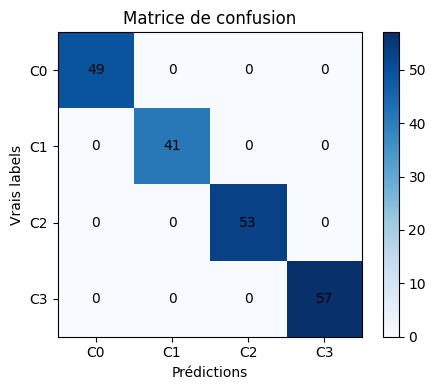

In [21]:
# Visualisation de la matrice de confusion
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(['C0','C1','C2','C3'])
ax.set_yticklabels(['C0','C1','C2','C3'])
ax.set_xlabel("Prédictions")
ax.set_ylabel("Vrais labels")
ax.set_title("Matrice de confusion")
for i in range(4):
    for j in range(4):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

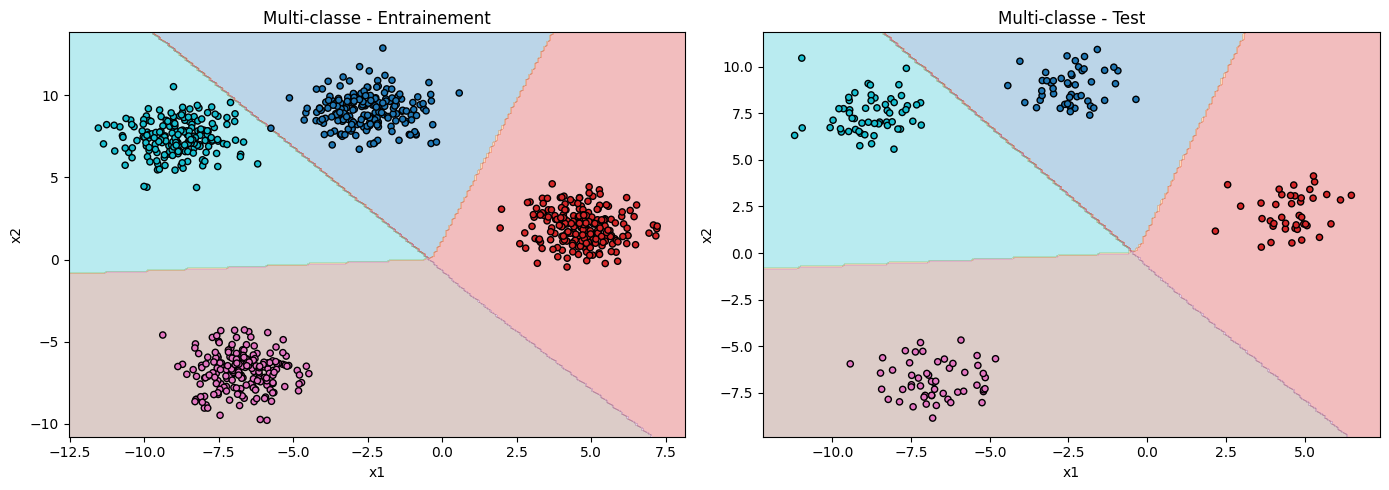

In [22]:
# 8. Frontières de décision pour la multi-classification
def plot_decision_boundary_mc(model, X, y, title, n_classes=4):
    h = 0.1
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
    Z = np.argmax(Z, axis=1).reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='tab10')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', edgecolors='k', s=20)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
plot_decision_boundary_mc(model_mc, X_mc_train, y_mc_train, "Multi-classe - Entrainement")

plt.sca(axes[1])
plot_decision_boundary_mc(model_mc, X_mc_test, y_mc_test, "Multi-classe - Test")

plt.tight_layout()
plt.show()

n=  100 | Test accuracy = 1.0000
n=  200 | Test accuracy = 1.0000
n=  500 | Test accuracy = 1.0000
n= 1000 | Test accuracy = 1.0000
n= 2000 | Test accuracy = 1.0000
n= 5000 | Test accuracy = 1.0000


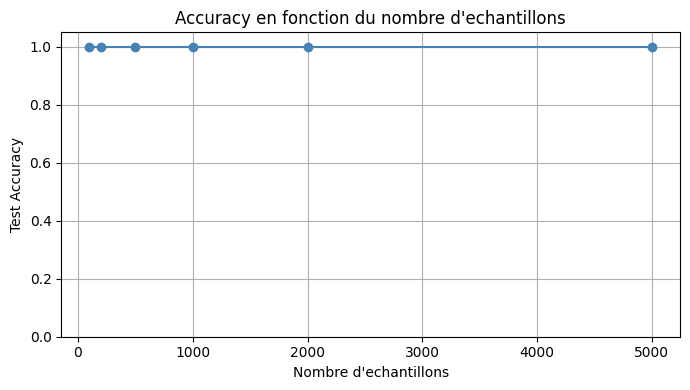

In [24]:
# 9. Impact du nombre d'échantillons sur l'exactitude
# On fait varier le nombre d'échantillons et on enregistre l'accuracy sur le test set

sample_sizes = [100, 200, 500, 1000, 2000, 5000]
accuracies   = []

for n in sample_sizes:
    X_n, y_n = make_blobs(n_samples=n, n_features=2, centers=4, random_state=42)
    X_n_train, X_n_test, y_n_train, y_n_test = train_test_split(
        X_n, y_n, test_size=0.2, random_state=42
    )

    m = Sequential([
        tf.keras.Input((2,)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(4,  activation='softmax')
    ])
    m.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    m.fit(X_n_train, y_n_train, epochs=100, verbose=0)

    _, acc = m.evaluate(X_n_test, y_n_test, verbose=0)
    accuracies.append(acc)
    print(f"n={n:>5} | Test accuracy = {acc:.4f}")

# Tracé de la courbe
plt.figure(figsize=(7, 4))
plt.plot(sample_sizes, accuracies, marker='o', color='steelblue')
plt.title("Accuracy en fonction du nombre d'echantillons")
plt.xlabel("Nombre d'echantillons")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1.05)
plt.grid(True)
plt.tight_layout()
plt.show()

**Observation :**

En général, l'accuracy augmente avec le nombre d'échantillons. Avec peu de données, le modèle peut sur-apprendre (overfitting) ou manquer de généralisation. A partir d'un certain seuil, l'accuracy se stabilise car le problème est relativement simple (blobs bien séparés).